In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Load dữ liệu
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Chọn User mẫu (dùng chung User với Tech Lead để thống nhất báo cáo)
user_id = 8792009665
df_user = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')

print(f"Đang phân tích thống kê chuyên sâu cho User {user_id}")

Đang phân tích thống kê chuyên sâu cho User 8792009665


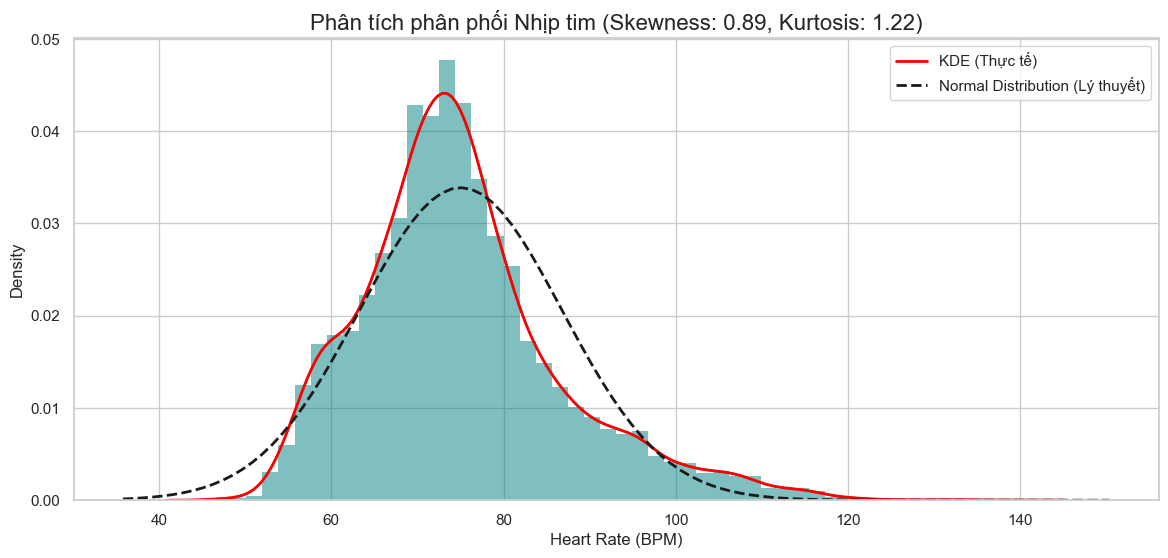

Nhận xét: Skewness = 0.89. 
-> Phân phối lệch phải (Right Skewed): Có nhiều giá trị nhịp tim cao đột biến (lúc tập luyện).


In [3]:
from scipy import stats

# 1. Vẽ Histogram kết hợp đường cong mật độ (KDE)
plt.figure(figsize=(14, 6))

# Vẽ biểu đồ
sns.histplot(df_user['Heart_Rate'], bins=50, kde=True, color='teal', stat="density", linewidth=0)
sns.kdeplot(df_user['Heart_Rate'], color='red', linewidth=2, label='KDE (Thực tế)')

# Vẽ đường phân phối chuẩn lý thuyết (để so sánh)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, df_user['Heart_Rate'].mean(), df_user['Heart_Rate'].std())
plt.plot(x, p, 'k', linewidth=2, linestyle='--', label='Normal Distribution (Lý thuyết)')

# Tính độ lệch (Skewness) và độ nhọn (Kurtosis)
skewness = df_user['Heart_Rate'].skew()
kurtosis = df_user['Heart_Rate'].kurtosis()

plt.title(f'Phân tích phân phối Nhịp tim (Skewness: {skewness:.2f}, Kurtosis: {kurtosis:.2f})', fontsize=16)
plt.xlabel('Heart Rate (BPM)')
plt.legend()
plt.show()

print(f"Nhận xét: Skewness = {skewness:.2f}. ")
if skewness > 0:
    print("-> Phân phối lệch phải (Right Skewed): Có nhiều giá trị nhịp tim cao đột biến (lúc tập luyện).")
elif skewness < 0:
    print("-> Phân phối lệch trái (Left Skewed).")
else:
    print("-> Phân phối khá cân đối.")

C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1424468535.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_idx = pd.date_range(start=df_user.index.min(), end=df_user.index.max(), freq='1T')


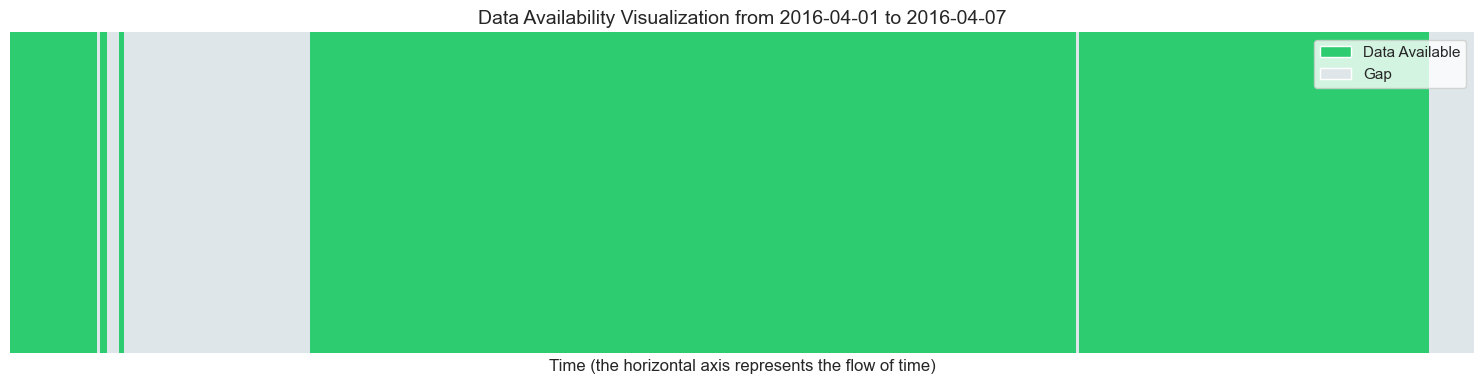

In [5]:
# Tạo index đầy đủ từng phút
full_idx = pd.date_range(start=df_user.index.min(), end=df_user.index.max(), freq='1T')
df_full = df_user.reindex(full_idx)

# Tạo biến đánh dấu: 1 là có dữ liệu, 0 là mất (NaN)
df_full['Availability'] = df_full['Heart_Rate'].notnull().astype(int)

# Chọn 1 tuần để vẽ cho rõ (thay vì vẽ cả tháng sẽ bị dày đặc)
start_zoom = '2016-04-01'
end_zoom = '2016-04-07'
df_zoom = df_full[start_zoom:end_zoom]

plt.figure(figsize=(15, 4))

# Vẽ biểu đồ nhiệt 1 chiều (giống mã vạch)
# Chúng ta dùng heatmap của seaborn, nhưng reshape dữ liệu thành 1 hàng
sns.heatmap(df_zoom['Availability'].values.reshape(1, -1), 
            cmap=['#dfe6e9', '#2ecc71'],  # Xám là mất, Xanh là có
            cbar=False, 
            xticklabels=False, yticklabels=False)

plt.title(f'Data Availability Visualization from {start_zoom} to {end_zoom}', fontsize=14)
plt.xlabel('Time (the horizontal axis represents the flow of time)', fontsize=12)

# Thêm chú thích thủ công
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Data Available'),
                   Patch(facecolor='#dfe6e9', label='Gap')]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

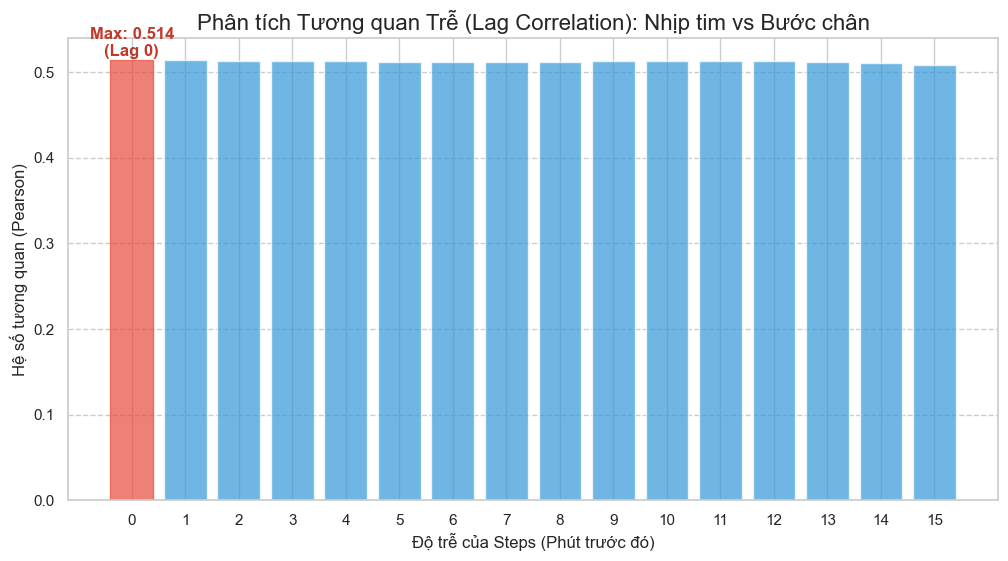

Kết luận: Nhịp tim tương quan mạnh nhất với mức vận động của 0 phút trước đó.


In [4]:
# Tính Cross-Correlation thủ công cho các độ trễ (lags) từ 0 đến 15 phút
lags = range(0, 16) # 0 đến 15 phút
corrs = []

for lag in lags:
    # Corr(HR_t, Steps_{t-lag})
    c = df_user['Heart_Rate'].corr(df_user['Steps'].shift(lag))
    corrs.append(c)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
bars = plt.bar(lags, corrs, color='#3498db', alpha=0.7)

# Highlight thanh cao nhất (Max Correlation)
max_corr = max(corrs)
max_lag = lags[corrs.index(max_corr)]
bars[max_lag].set_color('#e74c3c') # Tô đỏ thanh cao nhất

plt.title('Phân tích Tương quan Trễ (Lag Correlation): Nhịp tim vs Bước chân', fontsize=16)
plt.xlabel('Độ trễ của Steps (Phút trước đó)', fontsize=12)
plt.ylabel('Hệ số tương quan (Pearson)', fontsize=12)
plt.xticks(lags)
plt.grid(axis='y', linestyle='--')

# Thêm text chú thích
plt.text(max_lag, max_corr + 0.005, f'Max: {max_corr:.3f}\n(Lag {max_lag})', 
         ha='center', color='#c0392b', fontweight='bold')

plt.show()

print(f"Kết luận: Nhịp tim tương quan mạnh nhất với mức vận động của {max_lag} phút trước đó.")